In [2]:
import pandas as pd
df1 = pd.read_csv(r'C:\Users\LENOVO\Downloads\SB16 LLC Tabit Import.csv')
df1.head(2)

,Legal,PayGroup,Key,E_*_ORRate,LaborDescription99,E_Tipped Reg_Hours,E_Train_Hours,E_Overtime_Hours,#OT200,#CreditTips,#AutoGratuity,#DeclaredTips,#TipsReceived,#BusinessDate,E_*_ORPremium
0,1001318,Semi-Monthly,4,18.5,Line Cook,5.700000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2026-04-01,NaN
1,1001318,Semi-Monthly,53,18.0,Prep Cook,4.216667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2026-04-01,NaN


In [3]:
df2 = pd.read_csv(r'C:\Users\LENOVO\Downloads\Grandbar LLC Tabit Import.csv')
df2.head(2)

,Legal,PayGroup,Key,E_*_ORRate,LaborDescription99,E_Tipped Reg_Hours,E_Train_Hours,E_Overtime_Hours,#OT200,#CreditTips,#AutoGratuity,#DeclaredTips,#TipsReceived,#BusinessDate,E_*_ORPremium
0,1001317,Semi-Monthly,24,12.15,Catering Bartender,4.533333,0,0.0,0.0,0.0,0.0,20.0,0.0,2026-04-01,NaN
1,1001317,Semi-Monthly,14,12.15,Catering Bartender,3.483333,0,0.0,0.0,0.0,0.0,79.0,0.0,2026-04-01,NaN


In [4]:
# Create fucnction
import re
import pandas as pd

def clean():
    df1 = pd.read_csv(r'C:\Users\LENOVO\Downloads\SB16 LLC Tabit Import.csv')
    df2 = pd.read_csv(r'C:\Users\LENOVO\Downloads\Grandbar LLC Tabit Import.csv')
    
    #  compile regex (your style)
    pattern1 = re.compile(r'[^A-Za-z0-9_]+')
    pattern2 = re.compile(r'_+')
    
    # clean column names
    df1.columns = [pattern2.sub('_', pattern1.sub('_', i)).strip('_') for i in df1.columns]
    df2.columns = [pattern2.sub('_', pattern1.sub('_', i)).strip('_') for i in df2.columns]
    
    #  drop unwanted column
    df1 = df1.drop(columns=['E_ORPremium'], errors='ignore')
    df2 = df2.drop(columns=['E_ORPremium'], errors='ignore')
    
    # keep common columns (order preserved)
    common_columns = [i for i in df1.columns if i in df2.columns]
    
    df1 = df1[common_columns]
    df2 = df2[common_columns]
    
    return df1, df2

In [5]:
df1, df2 = clean()

In [6]:
print(df1.columns)
df1.columns

Index(['Legal', 'PayGroup', 'Key', 'E_ORRate', 'LaborDescription99',
       'E_Tipped_Reg_Hours', 'E_Train_Hours', 'E_Overtime_Hours', 'OT200',
       'CreditTips', 'AutoGratuity', 'DeclaredTips', 'TipsReceived',
       'BusinessDate'],
      dtype='object')


Index(['Legal', 'PayGroup', 'Key', 'E_ORRate', 'LaborDescription99',
       'E_Tipped_Reg_Hours', 'E_Train_Hours', 'E_Overtime_Hours', 'OT200',
       'CreditTips', 'AutoGratuity', 'DeclaredTips', 'TipsReceived',
       'BusinessDate'],
      dtype='object')

In [7]:
# Save
df1.to_csv('SB16 LLC Tabit Import Cleaned.csv', index=False, encoding='utf-8')
df2.to_csv('Grandbar LLC Tabit Import Cleaned.csv', index=False, encoding='utf-8')

# IMP
🔹 Backslash (\) in Regex

Backslash is used to change the meaning of characters in regex.

1. Make normal characters SPECIAL
   \d → digit (0–9)
   \s → whitespace
   \w → word character

2. Make special characters NORMAL (escape)
   \. → dot (.)
   \$ → dollar sign ($)
   \* → star (*)

🧠 Rule:
\ = change the meaning of a character

# re.search(pattern, string)
Scans anywhere in the string. Returns the first Match object, or None if nothing found.

In [8]:
# Extract the first number (Order ID)
import re
text = "Order ID: 4589 placed successfully 2345"

m = re.search(r'\d+', text)
if m: # check if m is not blank
    print(f'Without group: {m}') # without group
    print(f'With group: {m.group()}') # without group

Without group: <re.Match object; span=(10, 14), match='4589'>
With group: 4589


In [9]:
# Extract the discount percentage (number before %)
text = "Discount: 25% off on all items"

# \d+       → match one or more digits
# (?=%)     → positive lookahead → ensures that the digits are followed by '%'
# IMPORTANT → '%' is NOT included in the result, only used as a condition
m = re.search(r'\d+(?=%)', text)

if m:
    print(m.group())

25


In [119]:
# Extract only numbers that are followed by "kg" or "m"
text = "12kg 5m 30kg 7cm"

# \d+        → match digits
# (?=kg|m)   → positive lookahead → check if "kg" or "m" comes AFTER the number
# IMPORTANT  → "kg" or "m" is NOT included in the result

# re.search() → returns ONLY the FIRST match found in the string
m = re.search(r'\d+(?=kg|m)', text)

if m:
    print(m.group())   # Output: 12

12


In [134]:
logs = [
    "INFO start | ERROR 500 at /api",
    "WARNING timeout",
    "ERROR 404 at /home",
    "ERROR 500 at /login"
]

def extract(text):
    result = re.search(r'ERROR\s+(\d+)\s+at\s+(/\w+)', text)
    if result:
        return result.groups()
        

parsed = [i for i in map(extract, logs) if i is not None]
df = pd.DataFrame(parsed, columns=['Errors', 'Extension'])
df
    

,Errors,Extension
0,500,/api
1,404,/home
2,500,/login


# re.match(pattern, string)
Matches only at the very beginning of the string. If the pattern is not at position 0, it returns None

In [11]:
import re

# ❓ Question:
# Validate whether the given employee ID:
# - starts with 'EMP'
# - followed by exactly 3 digits
# - no extra characters allowed

text = "EMP1234"

# ^        → start of string (implicit in re.match)
# EMP      → must start with 'EMP'
# \d{3}    → exactly 3 digits (0–9)
# re.match → checks ONLY from the beginning of the string

m = re.match(r'EMP\d{3}', text)

# If match is found → valid
# If None → invalid
if m:
    print("Valid ID")
else:
    print("Invalid ID")

Valid ID


In [12]:
import pandas as pd
import re

# ❓ Task:
# From the emp_id column, extract only INVALID employee IDs
# Rule for valid ID:
# - must start with 'EMP'
# - followed by exactly 3 digits

df = pd.DataFrame({
    'emp_id': ['EMP123', 'EMP999', 'emp123', '123EMP']
})

# map() → applies function to each value in the column
# lambda x → processes each emp_id
# re.match(r'EMP\d{3}$', x) → checks if ID is valid
# not re.match(...) → True for INVALID IDs
# x if condition else None → keep invalid IDs, replace valid with None

invalid = df['emp_id'].map(lambda x: f'flagged {x}' if not re.match(r'EMP\d{3}$', x) else x)

invalid

0            EMP123
1            EMP999
2    flagged emp123
3    flagged 123EMP
Name: emp_id, dtype: object

In [13]:
# ❓ Task:
# From a list of employee IDs, identify and extract all INVALID IDs.
#
#   Valid ID Rules:
# - Must start with 'EMP'
# - Must be followed by exactly 4 digits
# - No extra characters before or after
#
# 🎯 Goal:
# Store all invalid employee IDs in a separate list and print them.

import re  # Import regex module for pattern matching

# List of employee IDs (contains both valid and invalid cases)
emp_ids = ['EMP1234', 'EMP999', 'emp1234', '123EMP', 'EMP5678']

flagged_id = []  # List to store invalid employee IDs

# Loop through each employee ID
for i in emp_ids:
    
    # Validate ID using regex:
    # ^EMP\d{4}$ → starts with 'EMP' + exactly 4 digits + nothing else
    if re.match(r'^EMP\d{4}$', i):
        continue  # Valid ID → skip
    
    else:
        # Invalid ID → add to flagged list
        flagged_id.append(i)

# Print all invalid employee IDs
print(flagged_id)

['EMP999', 'emp1234', '123EMP']


# re.fullmatch(pattern, string)
The entire string must match the pattern — not just part of it.

In [14]:
import re

# ❓ Task:
# Validate Employee ID using fullmatch()
# Rules:
# - must start with 'EMP'
# - followed by exactly 3 digits
# - no extra characters allowed

text = "EMP1234"

# re.fullmatch() → checks if the ENTIRE string matches the pattern
# EMP            → must start with 'EMP'
# \d{3}          → exactly 3 digits (0–9)
# No need for ^ and $ → fullmatch already enforces full string match

m = re.fullmatch(r'EMP\d{3}', text)

# If full match → valid ID
# If None → invalid ID
if m:
    print("Valid ID")
else:
    print("Invalid ID")

Invalid ID


# 🔹 Difference between re.match() and re.fullmatch()

# re.match() → checks pattern ONLY at the start of the string
# re.fullmatch() → checks pattern matches the ENTIRE string

import re

text = "EMP1234"

# match() → partial match allowed (only start is checked)
m1 = re.match(r'EMP\d{3}', text)

# fullmatch() → strict match (whole string must match)
m2 = re.fullmatch(r'EMP\d{3}', text)

print("match:", m1.group() if m1 else None)        # Output: EMP123
print("fullmatch:", m2.group() if m2 else None)    # Output: None

# re.findall(pattern, string)
Returns ALL matches as a plain Python list of strings

In [15]:
import re

# ❓ Question:
# From the given text, extract all numeric values (order IDs and amounts)

text = "Order 123 worth $45, Order 456 worth $78"

# re.findall() → returns ALL matches as a list
# \d+          → match one or more digits (numbers)
# No need for .group() → findall directly returns list of matches

m = re.findall(r'\d+', text)

# Output will be a list of all numbers found in the text
m

['123', '45', '456', '78']

In [16]:
# ❓ Task:
# From the given transaction text, extract ONLY the amounts that are in USD.
#
#   Conditions:
# - Extract only numeric values (amounts)
# - Include only those amounts which are followed by 'USD'
# - Do NOT include 'USD' in the output
# - Ignore other currencies like INR

import re  # Import regex module

# Input transaction text (mixed currencies)
text = "Order 101 worth 500USD, Order 102 worth 750INR, Order 103 worth 900USD"

# \d+        → match one or more digits (the amount)
# (?=USD)    → positive lookahead → ensure number is followed by 'USD'
#              (USD is checked but NOT included in result)

result = re.findall(r'\d+(?=USD)', text)

# Output: list of USD amounts only
result

['500', '900']

# re.finditer(pattern, string)
Like findall, but returns an iterator of Match objects (memory-efficient for large text).

In [13]:
# ❓ Task:
# From the given log text, extract all error messages along with their positions.
#
#   Requirements:
# - Capture the full error string (e.g., "ERROR 500")
# - Extract the position (index) where each error occurs in the text
# - There can be multiple errors in the same log string

import re  # Import regex module

# Log text containing multiple entries (INFO + ERROR)
log_text = "INFO User logged in | ERROR 500 at /api | INFO retry | ERROR 404 at /home"

# Pattern:
# ERROR\s\d{3} → match 'ERROR' + space + exactly 3 digits
pattern = r'ERROR\s\d{3}'

# finditer() → returns iterator of match objects (used to get both value and position)
for i in re.finditer(pattern, log_text):
    
    print(i.group())   # Full match (e.g., 'ERROR 500')
    print(i.start())   # Starting position of match
    print('----' * 20)

ERROR 500
22
--------------------------------------------------------------------------------
ERROR 404
55
--------------------------------------------------------------------------------


In [87]:
# ❓ Task:
# From the given system log text, extract all error codes along with their positions
# and convert the result into a structured DataFrame for analysis.
#
#   Requirements:
# - Capture only error codes (e.g., 500, 404)
# - Capture the starting index (position) of each error in the text
# - Store the results in a pandas DataFrame with columns:
#   ['index', 'errors']

import re
import pandas as pd

# Log data containing INFO, WARNING, and ERROR messages
log_text = "INFO start | ERROR 500 at /api | WARNING timeout | ERROR 404 at /home | ERROR 500 at /login"

# Pattern:
# ERROR\s(\d{3}) → match 'ERROR' followed by space and capture 3-digit code
pattern = r'ERROR\s(\d{3})'

data = []  # List to store extracted results

# Use finditer to get match objects (for value + position)
for i in re.finditer(pattern, log_text):
    data.append((i.start(), i.group(1)))  # (position, error_code)

# Convert list of tuples → DataFrame
df = pd.DataFrame(data, columns=['index', 'errors'])

df

,index,errors
0,13,500
1,51,404
2,72,500


In [90]:
# ❓ Task:
# Process log data line-by-line, extract error codes and endpoints,
# and aggregate counts using regex.

import re

logs = [
    "INFO start | ERROR 500 at /api",
    "WARNING timeout",
    "ERROR 404 at /home",
    "ERROR 500 at /login"
]

pattern = r'ERROR\s+(\d{3})\s+\w+\s+(/\w+)'

for i in logs:
    for k in re.finditer(pattern, i):
        print(k.group())
        print(k.group(1))

ERROR 500 at /api
500
ERROR 404 at /home
404
ERROR 500 at /login
500


# re.sub(pattern, replace, string, count=0)

In [20]:
import re

# ❓ Question:
# Clean the revenue text by removing currency symbols ($) and commas (,)
# so that numbers can be used for analysis

# Raw messy data
text = "Revenue: $1,200 and $3,450"

# re.sub() → replaces all matches of pattern with given value
# [$,]      → character set → match '$' OR ','
# ''        → replace with empty string (remove them)
# used \ before $ because $ is a regex character meaning end of string so using \ before $ to tell python to treat it as a normal charcater

clean = re.sub(r'[\$,]', '', text)

clean

'Revenue: 1200 and 3450'

In [21]:
import re

# ❓ Question:
# Remove all special characters and keep only letters, numbers, and spaces

text = "User@123! logged#in"

# [^A-Za-z0-9\s]
# ^        → NOT (exclude)
# A-Za-z   → letters
# 0-9      → digits
# \s       → whitespace
# → removes everything except letters, numbers, and spaces

clean = re.sub(r'[^A-Za-z0-9\s]', '', text)

clean

'User123 loggedin'

In [22]:
import re

# ❓ Question:
# Clean the text by replacing multiple spaces with a single space

text = "This   is    messy   text"

# re.sub() → replaces pattern with given value
# \s+       → one or more whitespace characters (space, tab, newline)
# ' '       → replace with a single space

clean = re.sub(r'\s+', ' ', text)

clean

'This is messy text'

In [23]:
# ❓ Task:
# Mask a credit card number by replacing only the first 12 digits with 'X'
# and keeping the last 4 digits visible (for security purposes)

import re  # Import regex module

# Input credit card string
text = "Card: 1234-5678-9012-3456"

# \d        → matches any digit (0–9)
# 'X'       → replacement character
# count=12  → replace ONLY first 12 digits, leave remaining unchanged

mask = re.sub(r'\d', 'X', text, count=12)

# Output: masked credit card (last 4 digits visible)
mask

'Card: XXXX-XXXX-XXXX-3456'

# re.split(pattern, string)
Split the string wherever the pattern matches — like str.split() but with regex power.


In [24]:
import re

# ❓ Question:
# Split the text into words by removing commas and spaces

text = "hello, world this,is python"

# re.split() → splits string based on pattern
# [,\s]+     → match comma (,) OR whitespace (\s)
# +          → one or more occurrences
# → handles multiple spaces or commas together

result = re.split(r'[,\s]+', text)

result

['hello', 'world', 'this', 'is', 'python']

# re.compile(pattern, flags=0)
Pre-compile a pattern into a reusable object. Use when you need the same pattern many times.

# 🧠 REGEX NOTES — Pattern + sub() + findall() + Multiple Patterns

# 🔹 re.compile(pattern)
# Pre-compiles a regex pattern into an object → faster + reusable
# pattern = re.compile(r'\d+')

# ------------------------------------------------------------

# 🔹 pattern.sub(REPLACEMENT, TEXT)
# Replace what the pattern MATCHES with the given replacement

# Syntax:
# pattern.sub('new_value', text)

# Example:
# pattern = re.compile(r'\d+')
# pattern.sub('_', "abc123xyz") → "abc_xyz"

# 👉 Important:
# pattern = WHAT TO FIND
# 'replacement' = WHAT TO REPLACE WITH

# ------------------------------------------------------------

# 🔹 pattern.findall(TEXT)
# Returns ALL matches as a list

# Example:
# pattern = re.compile(r'\d+')
# pattern.findall("a1b22c333") → ['1', '22', '333']

# 👉 If groups are used:
# returns list of tuples

# ------------------------------------------------------------

# 🔹 pattern.search(TEXT)
# Returns FIRST match only

# Example:
# pattern.search("abc123xyz") → match object (123)

# ------------------------------------------------------------

# 🔹 pattern.match(TEXT)
# Matches ONLY at beginning of string

# ------------------------------------------------------------

# 🔥 MULTIPLE (DOUBLE / TRIPLE) PATTERN CONCEPT

# Sometimes one pattern is NOT enough.
# We chain multiple patterns step by step.

# Example:

pattern1 = re.compile(r'[^A-Za-z0-9]+')  # remove special chars
pattern2 = re.compile(r'_+')             # fix multiple underscores

text = "__Hello--World!!!__"

# Step-by-step:
step1 = pattern1.sub('_', text)   # "__Hello_World__"
step2 = pattern2.sub('_', step1)  # "_Hello_World_"
final = step2.strip('_')          # "Hello_World"

# 👉 Why multiple patterns?
# 1st pattern → cleans junk
# 2nd pattern → fixes formatting
# 3rd step (strip) → cleans edges

# ------------------------------------------------------------

# 🔁 ONE-LINE (CHAINED)

# pattern2.sub('_', pattern1.sub('_', text)).strip('_')

# Execution order:
# INNER → OUTER
# pattern1 → pattern2 → strip

# ------------------------------------------------------------

# 🧩 KEY TAKEAWAYS

# ✔ pattern = what to match
# ✔ sub() = replace match
# ✔ findall() = extract all matches
# ✔ search() = first match
# ✔ multiple patterns = step-by-step cleaning
# ✔ strip() = remove from edges only



In [25]:
import re

logs = [
    "INFO start | ERROR 500 at /api",
    "WARNING timeout",
    "ERROR 404 at /home",
    "ERROR 500 at /login"
]

# Compile regex
pattern = re.compile(r'ERROR\s+(\d+)\s+\w+\s+(/\w+)')

for i in logs:
    for j in pattern.finditer(i):
        print(j.group(1))  # error code
        print(j.group(2)) # # endpoint
        print('--' * 20)

500
/api
----------------------------------------
404
/home
----------------------------------------
500
/login
----------------------------------------


In [26]:
# ❓ Task:
# From a DataFrame containing customer reviews, extract error-related features using regex.
#
# Requirements:
# - Extract all error codes (e.g., 500, 404)
# - Count occurrences of specific errors (500, 404)
# - Calculate total number of errors per review
# - Store results separately and merge back to original DataFrame

import re
import pandas as pd

# Sample dataset
df = pd.DataFrame({
    'review': [
        "Delivery was late. ERROR 500 occurred. Not happy.",
        "Great service! No issues.",
        "Payment failed ERROR 404 at checkout.",
        "ERROR 500 and ERROR 500 again"
    ]
})

# Compile regex (case-insensitive for ERROR/error)
# (\d{3}) → capture 3-digit error code
pattern = re.compile(r'error\s+(\d{3})', re.IGNORECASE)


# Function to extract features from each review
def extraction(text):
    
    # findall → returns list of matched error codes as strings
    result = pattern.findall(text)
    
    return {'Error Code': result,                        # list of error codes
        'Error count 500': result.count('500'),      # count of 500 errors
        'Error Count 404': result.count('404'),      # count of 404 errors
        'Error Length': len(result)                  # total number of errors
    }


# Apply function to each row in 'review' column
features = df['review'].apply(extraction)

# Convert Series of dictionaries → DataFrame
features_df = pd.DataFrame(features, index=df.index)

# Merge original data with extracted features
joined = pd.concat([df, features_df], axis=1)

# Final result
joined

,review,review
0,Delivery was late. ERROR 500 occurred. Not happy.,"{'Error Code': ['500'], 'Error count 500': 1, ..."
1,Great service! No issues.,"{'Error Code': [], 'Error count 500': 0, 'Erro..."
2,Payment failed ERROR 404 at checkout.,"{'Error Code': ['404'], 'Error count 500': 0, ..."
3,ERROR 500 and ERROR 500 again,"{'Error Code': ['500', '500'], 'Error count 50..."


In [27]:
features.to_list()

[{'Error Code': ['500'],
  'Error count 500': 1,
  'Error Count 404': 0,
  'Error Length': 1},
 {'Error Code': [],
  'Error count 500': 0,
  'Error Count 404': 0,
  'Error Length': 0},
 {'Error Code': ['404'],
  'Error count 500': 0,
  'Error Count 404': 1,
  'Error Length': 1},
 {'Error Code': ['500', '500'],
  'Error count 500': 2,
  'Error Count 404': 0,
  'Error Length': 2}]

In [28]:
features

0    {'Error Code': ['500'], 'Error count 500': 1, ...
1    {'Error Code': [], 'Error count 500': 0, 'Erro...
2    {'Error Code': ['404'], 'Error count 500': 0, ...
3    {'Error Code': ['500', '500'], 'Error count 50...
Name: review, dtype: object

# Match Object — All Methods

In [29]:
import re

# ❓ Question:
# Extract date from text and understand how match object methods work

text = "Date: 2024-03-15 in log"

# (\d{4}) → group 1 → year
# (\d{2}) → group 2 → month
# (\d{2}) → group 3 → day
# re.search() → finds first match anywhere in the string

m = re.search(r'(\d{4})-(\d{2})-(\d{2})', text)

# group() → full matched text
print(m.group())      # '2024-03-15'

# group(0) → same as full match
print(m.group(0))     # '2024-03-15'

# group(1) → first () → year
print(m.group(1))     # '2024'

# group(2) → second () → month
print(m.group(2))     # '03'

# group(3) → third () → day
print(m.group(3))     # '15'

# groups() → all captured groups as tuple
print(m.groups())     # ('2024', '03', '15')

# start() → starting index of match
print(m.start())      # 6

# end() → ending index of match
print(m.end())        # 16

# span() → (start, end) as tuple
print(m.span())       # (6, 16)

2024-03-15
2024-03-15
2024
03
15
('2024', '03', '15')
6
16
(6, 16)


# Special Characters (Metacharacters)

# Dot . = match ANY single character

In [30]:
import re

text = "cat cot cuut c9t c_t btt kt corn mat"

# ❓ Question:
# Understand how '.' works in regex and relate it to SQL LIKE

# c.t → c + ANY ONE character + t
# Equivalent SQL → LIKE 'c_t'
# - must start with 'c'
# - must end with 't'
# - exactly ONE character in between

print(re.findall(r'c.t', text))
# Output: ['cat', 'cot', 'c9t', 'c_t']


# c..t → c + ANY TWO characters + t
# Equivalent SQL → LIKE 'c__t'
# - exactly TWO characters between c and t

print(re.findall(r'c..t', text))
# Output: ['cuut']


# c. → c + ANY ONE character
# Equivalent SQL → LIKE 'c_'
# - finds all 2-letter combinations starting with 'c'

print(re.findall(r'c.', text))
# Output: ['ca', 'co', 'cu', 'c9', 'c_', 'co']


# .t → ANY ONE character + t
# Equivalent SQL → LIKE '_t'
# - finds all 2-letter combinations ending with 't'

print(re.findall(r'.t', text))
# Output: ['at', 'ot', 'ut', '9t', '_t', 'tt', 'kt', 'at']

['cat', 'cot', 'c9t', 'c_t']
['cuut']
['ca', 'co', 'cu', 'c9', 'c_', 'co']
['at', 'ot', 'ut', '9t', '_t', 'bt', 'kt', 'at']


# ^ Start of string 

In [31]:
import pandas as pd
import re

# ❓ Question:
# From product_code column, extract only codes that START with 'SKU'

df = pd.DataFrame({
    'product_code': ['SKU123', 'ABC456', 'SKU789', 'XYZ111', 'SKU000', '123SKU']
})

# filter() → keeps only values where condition is True
# lambda x → applies function to each product_code
# re.search(r'^SKU', x) → checks if string STARTS with 'SKU'
# ^ → start of string (very important for prefix matching)

result = list(filter(lambda x: re.findall(r'^SKU', x), df['product_code']))

result

['SKU123', 'SKU789', 'SKU000']

# $ End of string


In [32]:
import re

# ❓ Question:
# From a list of file names, return only those that END with 'csv'

files = [
    "sales_jan.csv",
    "report.pdf",
    "data.csv",
    "backup.csv_old",
    "summary.txt"
]

# filter() → keeps only values where condition is True
# lambda y → applies regex check to each file name
# re.findall(r'csv$', y) → checks if 'csv' is at the END of string
# $ → end of string
# NOTE: findall returns a list → non-empty = True, empty = False

filter_csv = lambda x: list(filter(lambda y: re.findall(r'csv$', y), x))

filter_csv(files)

['sales_jan.csv', 'data.csv']

# Difference between [ ] and [^ ] in Regex

## [ ] → INCLUDE (match what is inside)
Matches ANY ONE character from the given set.

Examples:
- `[abc]` → matches 'a' OR 'b' OR 'c'
- `[0-9]` → matches any digit (0–9)
- `[A-Z]` → matches any uppercase letter

Example in text:
- Pattern: `[aeiou]`
- Text: "data"
- Matches: 'a', 'a'

❗ Important:
- `[ab]` → matches 'a' OR 'b'
- ❌ Does NOT match "ab" together


---

## [^ ] → EXCLUDE (match what is NOT inside)
Matches ANY ONE character NOT in the set.

Examples:
- `[^abc]` → matches anything except 'a', 'b', 'c'
- `[^0-9]` → matches non-digits
- `[^A-Z]` → matches anything except uppercase letters

Example in text:
- Pattern: `[^aeiou]`
- Text: "data"
- Matches: 'd', 't'


---

## ⚠️ Important Notes

- `[abc]` → matches ONE character, not "abc"
- `[ab]+` → matches sequence like 'a', 'b', 'ab', 'ba'
- `[^ ]` works only inside brackets


---

## Key Rule

- `[ ]` = what you WANT  
- `[^ ]` = what you DON'T want  


---

## Quick Summary

- `[ab]` → 'a' or 'b' (not "ab")
- `[^ab]` → anything except 'a' or 'b'
- `[0-9]` → digits  
- `[^0-9]` → non-digits

🔥 KEY RULE (VERY IMPORTANT)

👉 Inside [], most special characters lose their meaning
👉 They are treated as normal characters

# Example with $
inside []
re.findall(r'[$]') - here no need to use escape chracter \ before $ to treat it as bomral dollar sign as it is inside brackets

outside []
re.findall(r'\$')

In [33]:
import pandas as pd
import re

# ❓ Question:
# Extract all numeric values from the raw_text column

df = pd.DataFrame({
    'raw_text': [
        'Order A123B',
        'User456Name',
        'Item789X'
    ]
})

# map() → applies function to each row
# lambda x → processes each string
# re.findall(r'[0-9]+', x) →
#   [0-9]+ → one or more digits
#   returns a LIST of all numbers found

df['raw_text'] = df['raw_text'].map(lambda x: re.findall(r'[0-9]+', x))

df

,raw_text
0,[123]
1,[456]
2,[789]


In [34]:
import pandas as pd
import re

# ❓ Question:
# Clean the text by removing all special characters
# Keep only letters (A–Z, a–z) and numbers (0–9)

df = pd.DataFrame({
    'raw_text': [
        'User@123!',
        'Data#456$',
        'Clean789%'
    ]
})

# map() → applies function to each row
# lambda x → processes each string
# re.sub() → replaces matched pattern with ''
# [^A-Za-z0-9]+ →
#   ^ → NOT (exclude)
#   A-Za-z → letters
#   0-9 → digits
#   + → one or more unwanted characters
# → removes all special characters

df['raw_text'] = df['raw_text'].map(lambda x: re.sub(r'[^A-Za-z0-9]+', '', x))

df

,raw_text
0,User123
1,Data456
2,Clean789


# Regex Quantifiers Cheat Sheet

These symbols define how many times a pattern should repeat.

## * → 0 or more repetitions (greedy)
Matches even if the character is not present.

Example:  
r'ab*' → 'a', 'ab', 'abb', 'abbb'  
(b can appear 0 or more times)

---

## + → 1 or more repetitions (greedy)
Requires at least one occurrence.

Example:  
r'ab+' → 'ab', 'abb', 'abbb'  
❌ does NOT match 'a'

---

## ? → 0 or 1 (optional)
Makes the preceding character optional.

Example:  
r'colou?r' → matches both 'color' and 'colour'

---

## Key Difference
* → can be zero  
+ → must be at least one  
? → optional (only one)

---

🎯 One-line memory trick

👉 * = maybe many
👉 + = must have
👉 ? = optional one
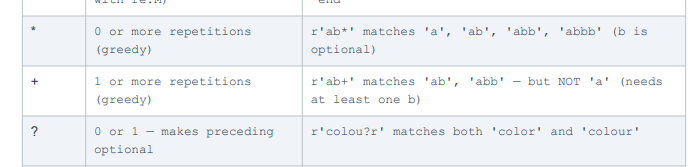

In [35]:
# ❓ Task:
# Extract product codes starting with 'PROD'
# followed by zero or more digits
# 'PROD' alone should also be valid

import re

data = [
    "PROD123 shipped",
    "PROD out of stock",
    "PROD9999 delivered",
    "INVALID123"
]

# compile regex (case-insensitive)
# PROD → fixed prefix
# \d* → zero or more digits (allows 'PROD' also)
pattern = re.compile(r'PROD\d*', re.IGNORECASE)

# findall → returns all matches in each string
# list comprehension → apply pattern on each row
result = [pattern.findall(i) for i in data]

# output: list of matches per row
result

[['PROD123'], ['PROD'], ['PROD9999'], []]

In [36]:
# ❓ Task:
# Extract product codes where:
# - Code starts with 'PROD'
# - Must be followed by one or more digits
# - 'PROD' alone should NOT be valid

import re

data = [
    "PROD123 shipped",
    "PROD out of stock",
    "PROD9999 delivered",
    "INVALID123"
]

# compile regex
# PROD → fixed prefix
# \d+ → one or more digits (at least 1 required)
pattern = re.compile(r'PROD\d+', re.IGNORECASE)

# apply pattern to each string
result = [pattern.findall(i) for i in data]

result

[['PROD123'], [], ['PROD9999'], []]

# 🧠 Difference between * and +
# * → allows zero or more digits
#     'PROD'      ✅ valid (no digits)
#     'PROD123'   ✅ valid

# + → requires at least one digit
#     'PROD'      ❌ invalid (no digits)
#     'PROD123'   ✅ valid

# 🎯 Key takeaway:
# * = optional digits
# + = mandatory digits

In [37]:
# ❓ Task:
# Extract color names where:
# - Both American and British spelling should be valid
# - 'color' and 'colour' should both match

import re

data = [
    "I like this color",
    "I like this colour",
    "colr is wrong",
    "colorful design"
]

# findall → returns list of matches for each string
# if match exists → return list (e.g., ['color'])
# if no match → return None
result = [re.findall(r'colou?r', x) if re.findall(r'colou?r', x) else None for x in data]

# output:
# ['color']  → match found
# ['colour'] → match found
# None       → no match
# ['color']  → match inside 'colorful'
result

# colou?r → 'u' is optional
# matches: color, colour
# also matches inside words like 'colorful'

[['color'], ['colour'], None, ['color']]

# Regex Quantifiers {n}, {n,}, {n,m}

These define exact or range-based repetitions.

## {n} → Exactly n repetitions
Matches the pattern exactly n times.

Example:
- `\d{3}` → exactly 3 digits  
  Matches: 123, 456  
  ❌ Does NOT match: 12, 1234

---

## {n,} → n or more repetitions
Matches at least n times.

Example:
- `\d{3,}` → 3 or more digits  
  Matches: 123, 1234, 12345  
  ❌ Does NOT match: 12

---

## {n,m} → Between n and m repetitions
Matches between n and m times (inclusive).

Example:
- `\d{2,4}` → 2 to 4 digits  
  Matches: 12, 123, 1234  
  ❌ Does NOT match: 1, 12345

---

## Key Difference

- `{n}` → fixed length  
- `{n,}` → minimum length  
- `{n,m}` → range

---

## Quick Summary

- `{3}` → exactly 3  
- `{3,}` → 3 or more  
- `{2,4}` → between 2 and 4
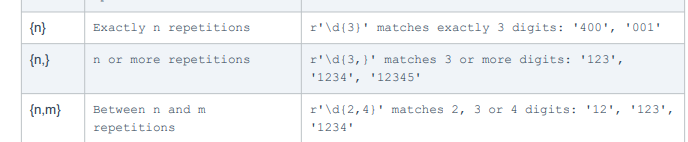

In [38]:
# ❓ Task:
# Extract valid PIN codes where:
# - PIN must be exactly 4 digits
# - Ignore invalid ones (less or more digits)

import re

data = [
    "PIN: 1234",
    "PIN: 567",
    "PIN: 98765",
    "PIN: 4321"
]

# \d{4} → exactly 4 digits
pattern = re.compile(r'\d{4}')

result = [pattern.findall(x) for x in data]

result

[['1234'], [], ['9876'], ['4321']]

In [39]:
# ❓ Task:
# From transaction logs, extract valid Transaction IDs where:
# - ID starts with 'TXN'
# - Followed by 2 to 5 digits
# - Ignore invalid IDs (too short or too long)

import re
import pandas as pd

df = pd.DataFrame({
    'log': [
        "Payment success TXN12 completed",
        "Refund issued TXN1234 processed",
        "Error TXN1 failed",
        "Payment TXN123456 invalid",
        "TXN99 approved"
    ]
})

# TXN\d{2,5} → 'TXN' + 2 to 5 digits
# findall → returns list of matches
# if no match → return None

fuc = lambda x: re.findall(r'TXN\d{2,5}', x) if re.findall(r'TXN\d{2,5}', x) else None

# apply function on column
df['result'] = df['log'].apply(fuc)

df

,log,result
0,Payment success TXN12 completed,[TXN12]
1,Refund issued TXN1234 processed,[TXN1234]
2,Error TXN1 failed,None
3,Payment TXN123456 invalid,[TXN12345]
4,TXN99 approved,[TXN99]


## Escape Sequences (\d, \w, \s ...)

# \d Any digit [0-9] 

In [40]:
import pandas as pd
import re

# ❓ Question:
# Extract numeric values (quantities) from order_info text

df = pd.DataFrame({
    'order_info': [
        'Order 3 items',
        'Bought 12 units',
        'Returned 1 item',
        'Purchased 25 products'
    ]
})

# map() → applies function to each row
# lambda x → processes each string
# re.findall(r'\d+', x) →
#   \d → digit (0–9)
#   + → one or more digits
#   findall → returns ALL matches as a list

df['order_info'] = df['order_info'].map(lambda x: re.findall(r'\d+', x))

df

,order_info
0,[3]
1,[12]
2,[1]
3,[25]


# \D Any NON-digit
[^0-9]

In [41]:
import pandas as pd
import re

# ❓ Question:
# Remove digits from text using \D logic

df = pd.DataFrame({
    'text': [
        'User123',
        'Data456',
        'Item789'
    ]
})

# map() → applies function to each row
# re.sub(pattern, '', x) → replaces pattern with empty string

# [^\D]+ →
#   \D → NOT digit
#   [^] means exclude anything I write inside with [^], [^\D] exclude non digits
#   + → one or more digits

# So this pattern is actually same as: \d+
# → removes digits

df['text'] = df['text'].map(lambda x: re.sub(r'[^\D]+', '', x))

df

,text
0,User
1,Data
2,Item


# \w Word char
[a-zA-Z0-9_]


In [42]:
import pandas as pd
import re

# ❓ Question:
# From messy text, extract only "word tokens"
# (words, numbers, and underscores — ignore special characters like @, -, !, #, $)

df = pd.DataFrame({
    'text': [
        'User_123 logged-in!',
        'Data@456 processed#',
        'Item_789 ready$'
    ]
})

# map() → applies function to each row
# lambda x → processes each string

# re.findall(r'\w+', x) →
#   \w → word character (A–Z, a–z, 0–9, _)
#   + → one or more characters
#   findall → returns ALL matching words as a list

# Special characters like @, -, ! are automatically ignored

df['text'] = df['text'].map(lambda x: re.findall(r'\w+', x))

df

,text
0,"[User_123, logged, in]"
1,"[Data, 456, processed]"
2,"[Item_789, ready]"


# Whitespace [\t\n\r]
# \S NON-whitespace 
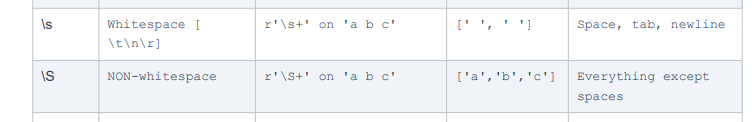

In [43]:
import pandas as pd
import re

# ❓ Question:
# Clean messy text by replacing multiple spaces with a single space

df = pd.DataFrame({
    'text': [
        'This   is   messy',
        'Too    many   spaces',
        'Clean   this   text'
    ]
})

# map() → applies function row-wise
# lambda x → processes each string

# re.sub(r'\s+', ' ', x) →
#   \s → whitespace (space, tab, newline)
#   + → one or more spaces
#   ' ' → replace with single space

# Effect:
# "This   is   messy" → "This is messy"

df['text'] = df['text'].map(lambda x: re.sub(r'\s+', ' ', x))

df

,text
0,This is messy
1,Too many spaces
2,Clean this text


In [44]:
import pandas as pd
import re

df = pd.DataFrame({
    'text': [
        'This is messy',
        'Too many spaces',
        'Clean this text'
    ]
})

df['text'] = df['text'].map(lambda x: re.findall(r'\S+', x))

df

,text
0,"[This, is, messy]"
1,"[Too, many, spaces]"
2,"[Clean, this, text]"


# \b Word boundary

In [45]:
import pandas as pd
import re

df = pd.DataFrame({
    'description': [
        'big sale today',
        'wholesale market',
        'flash sale now',
        'sales report',
        'seasonal sale'
    ]
})

df_filtered = df[df['description'].str.contains(r'\bsale\b', regex=True, na=False)]
df_filtered

,description
0,big sale today
2,flash sale now
4,seasonal sale


In [46]:
# ❓ Task:
# From customer support logs, extract valid Customer IDs where:
# - Format: CUST + space + 4 digits (e.g., "CUST 1234")
# - Logs are messy with extra text
# - Create a function and apply on DataFrame

import re
import pandas as pd

df = pd.DataFrame({
    'log': [
        "User complaint from CUST 1234 regarding delay",
        "Resolved issue for CUST 5678 successfully",
        "Invalid entry CUST123",
        "Escalation for CUST 9999 pending",
        "No customer ID here"
    ]
})

def clean(text):
    pattern = re.compile(r'cust\s+\d{4}', re.IGNORECASE)
    result = pattern.findall(text)
    for i in result:
        return i.replace(' ', '')


df['result'] = df['log'].apply(clean)
df

,log,result
0,User complaint from CUST 1234 regarding delay,CUST1234
1,Resolved issue for CUST 5678 successfully,CUST5678
2,Invalid entry CUST123,None
3,Escalation for CUST 9999 pending,CUST9999
4,No customer ID here,None


# Quantifiers — Greedy vs Lazy

Quantifiers control how many times a pattern repeats.  
Key idea: Greedy vs Lazy behavior.

---

## Greedy (default)

Takes as MUCH as possible.

Examples:
- `*` → 0 or more (greedy)
- `+` → 1 or more (greedy)
- `{n,m}` → range (greedy)

Example:
Pattern: `a+`  
Text: `aaa`  
Result: `['aaa']`  
→ takes everything in one go

---

## Lazy (Non-Greedy)

Takes as LITTLE as possible.  
Add `?` after quantifier.

Examples:
- `*?` → lazy
- `+?` → lazy
- `{n,m}?` → lazy

Example:
Pattern: `a+?`  
Text: `aaa`  
Result: `['a', 'a', 'a']`  
→ takes one at a time

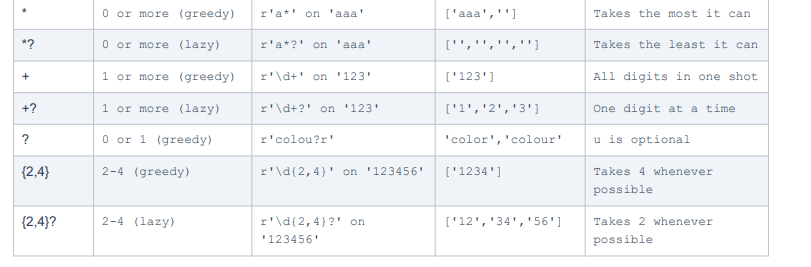

In [47]:
# ❓ Task: Extract customer reviews from HTML tags using a greedy regex pattern (*)

import re                          # Import regex module for pattern matching
import pandas as pd               # Import pandas for DataFrame handling

df = pd.DataFrame({               # Create a DataFrame
    'review_html': [              # Column name: review_html
        "<p>Great product</p>",   # Row 1: Single HTML tag
        "<div>Bad service</div>", # Row 2: Single HTML tag
        "<p>Fast delivery</p><p>Nice packaging</p>"  # Row 3: Multiple HTML tags
    ]
})

pattern = re.compile(r'<.*>')     # Compile greedy regex pattern:
                                  # <   → match opening angle bracket
                                  # .*  → match ANY character (greedy → max possible)
                                  # >   → match closing angle bracket

df['extracted'] = df['review_html'].apply(  # Create new column 'extracted'
    lambda x: pattern.findall(x)            # For each row, find all matches using regex
)                                          # findall() returns matches as a list

df                                         # Display the final DataFrame

,review_html,extracted
0,<p>Great product</p>,[<p>Great product</p>]
1,<div>Bad service</div>,[<div>Bad service</div>]
2,<p>Fast delivery</p><p>Nice packaging</p>,[<p>Fast delivery</p><p>Nice packaging</p>]


In [48]:
# ❓ Task:
# You are given customer reviews inside HTML tags.
# Extract the content using lazy pattern (*?)

import re
import pandas as pd

df = pd.DataFrame({
    'review_html': [
        "<p>Great product</p>",
        "<div>Bad service</div>",
        "<p>Fast delivery</p><p>Nice packaging</p>"
    ]
})


df['clean_review'] = df['review_html'].apply(lambda x: re.sub(r'<.+?>', '', x))
df

,review_html,clean_review
0,<p>Great product</p>,Great product
1,<div>Bad service</div>,Bad service
2,<p>Fast delivery</p><p>Nice packaging</p>,Fast deliveryNice packaging


In [49]:
# ❓ Task: Extract customer reviews from HTML tags using a lazy regex pattern (*?)

import re                          # Import regex module to work with patterns
import pandas as pd               # Import pandas to handle structured data

df = pd.DataFrame({               # Create a DataFrame
    'review_html': [              # Column containing HTML reviews
        "<p>Great product</p>",   # Row 1: Single tag
        "<div>Bad service</div>", # Row 2: Single tag
        "<p>Fast delivery</p><p>Nice packaging</p>"  # Row 3: Multiple tags
    ]
})

df['clean_review'] = df['review_html'].apply(      # Create new column 'clean_review'
    lambda x: re.sub(r'<.*?>', '', x)              # Replace HTML tags with empty string
                                                   # <      → start of tag
                                                   # .*?    → match ANY char (lazy → minimum possible)
                                                   # >      → end of tag
                                                   # ''     → replace with nothing (remove tags)
)                                                  # apply() runs this logic on each row

df                                                 # Display final cleaned DataFrame

,review_html,clean_review
0,<p>Great product</p>,Great product
1,<div>Bad service</div>,Bad service
2,<p>Fast delivery</p><p>Nice packaging</p>,Fast deliveryNice packaging


In [50]:
# ❓ Task: Extract text inside double quotes using regex

import re                          # Import regex module
import pandas as pd               # Import pandas for DataFrame

# Create sample data
df = pd.DataFrame({
    'chat': [
        'User said "hello" and then "bye"',          # Two quoted texts
        'Agent replied "ok"',                        # One quoted text
        'Customer wrote "not happy" then "refund needed"'  # Two quoted texts
    ]
})

# ❌ IMPORTANT: This is GREEDY pattern (not lazy)
# r'".*"' means:
# "     → match starting quote
# .*    → match ANY character (greedy → takes maximum possible, including ")
# "     → match ending quote (last possible one)

pattern = re.compile(r'".*"')

# Apply regex on each row
df['extracted_quotes'] = df['chat'].apply(
    lambda x: pattern.findall(x)   # findall() finds all matches in the string
)

df

,chat,extracted_quotes
0,"User said ""hello"" and then ""bye""","[""hello"" and then ""bye""]"
1,"Agent replied ""ok""","[""ok""]"
2,"Customer wrote ""not happy"" then ""refund needed""","[""not happy"" then ""refund needed""]"


In [51]:
# ❓ Task: Extract text inside double quotes using regex

import re                          # Import regex module (pattern matching)
import pandas as pd               # Import pandas (DataFrame operations)

# Create sample data
df = pd.DataFrame({
    'chat': [
        'User said "hello" and then "bye"',          # Two quoted texts
        'Agent replied "ok"',                        # One quoted text
        'Customer wrote "not happy" then "refund needed"'  # Two quoted texts
    ]
})

# ✅ IMPORTANT: This is LAZY pattern
# r'".*?"' means:
# "      → match starting double quote
# .*?    → match ANY character (lazy → takes minimum possible, stops early)
# "      → match ending double quote (first possible one)

pattern = re.compile(r'".*?"')   # Compile lazy regex pattern

# Apply regex on each row
df['extracted_quotes'] = df['chat'].apply(
    lambda x: pattern.findall(x)   # findall() finds ALL matches one by one
)

df                                  # Display result

,chat,extracted_quotes
0,"User said ""hello"" and then ""bye""","[""hello"", ""bye""]"
1,"Agent replied ""ok""","[""ok""]"
2,"Customer wrote ""not happy"" then ""refund needed""","[""not happy"", ""refund needed""]"


# Greedy vs Lazy — HTML Parsing Example (the classic example)

In [52]:
# This is the most important example to understand greedy vs lazy:
import re
html = '<b>bold</b> and <i>italic</i>'

re.findall(r'<.+>', html)

['<b>bold</b> and <i>italic</i>']

In [53]:
import re
html = '<b>bold</b> and <i>italic</i>'

re.findall(r'<.>', html)

['<b>', '<i>']

In [54]:
import re
html = '<b>bold</b> and <i>italic</i>'

re.findall(r'<.*>', html)

['<b>bold</b> and <i>italic</i>']

In [55]:
import re
html = '<b>bold</b> and <i>italic</i>'

re.findall(r'<.*?>', html)

['<b>', '</b>', '<i>', '</i>']

# 📝 Greedy vs Lazy Regex — Why All 4 Patterns Behave Differently

html = '<b>bold</b> and <i>italic</i>'

1) Pattern: <.+>
re.findall(r'<.+>', html)
Output: ['<b>bold</b> and <i>italic</i>']

Explanation:
- . = one dot any single character
- + = one or more greedy (take as much as possible)
- Starts at FIRST '<'
- Then .+ keeps consuming everything (including >, <, /) till last > in the string
- Stops at LAST '>'
👉 Result: ONE BIG MATCH (because greedy overshoots)

--------------------------------------------------

2) Pattern: <.>
re.findall(r'<.>', html)
Output: ['<b>', '<i>']

Explanation:
- . = exactly ONE character
- Matches only tags with 1 character inside
  ✔ <b>, <i>
  ❌ </b>, </i> (because they have 2 characters: /b)
👉 Result: Only opening tags

--------------------------------------------------

3) Pattern: <.*>
re.findall(r'<.*>', html)
Output: ['<b>bold</b> and <i>italic</i>']

Explanation:
- .* = 0 or more greedy
- Same behavior as .+ but allows even empty
- Starts at FIRST '<'
- Eats everything till LAST '>' in the string not limited to a single patern <>. As I have <>m > as the ending it will go till last >
👉 Result: ONE BIG MATCH (greedy again)

--------------------------------------------------

4) Pattern: <.*?>
re.findall(r'<.*?>', html)
Output: ['<b>', '</b>', '<i>', '</i>']

Explanation:
- *? = lazy (take minimum possible)
- Starts at '<'
- Stops at FIRST '>' it finds
- Then continues searching again
👉 Result: Each tag separately (CORRECT)

--------------------------------------------------

🔥 FINAL UNDERSTANDING

Greedy (.* or .+) → takes MAX → first < to last >
Lazy (*?)         → takes MIN → stops at first >

👉 Regex does NOT understand HTML structure
👉 It only follows pattern rules

--------------------------------------------------

⚡ GOLDEN RULE

For HTML/XML parsing:
✔ Always use LAZY → <.*?>
❌ Avoid greedy → <.*> or <.+>

# Few orther examples

In [56]:
text = "start MATCH1 end start MATCH2 end"   # Sample string with two patterns

re.findall(r'start\s\w+\s+end+?', text)      # Regex explanation:
                                            # start   → match the word "start"
                                            # \s      → match one space after "start"
                                            # \w+     → match word characters (greedy → MATCH1 / MATCH2 fully)
                                            # \s+     → match one or more spaces before "end"
                                            # end+?   → match "end"
                                            #           'en' is fixed
                                            #           'd+?' → lazy, but only one 'd' exists → no real difference
                                            # findall() → finds all matches in the string

# Output:
# ['start MATCH1 end', 'start MATCH2 end']

['start MATCH1 end', 'start MATCH2 end']

In [57]:
text = "start MATCH1 end start MATCH2 end"   # Sample string with two patterns

re.findall(r'start.+end', text)              # Regex explanation:
                                            # start   → match the word "start"
                                            # .       → match ANY character (including space)
                                            # +       → one or more (GREEDY → take as much as possible)
                                            # end     → match the word "end"
                                            #
                                            # Flow:
                                            # 1. Starts at FIRST "start"
                                            # 2. .+ keeps consuming EVERYTHING (MATCH1 end start MATCH2)
                                            # 3. Stops at LAST "end" to complete pattern
                                            #
                                            # findall() → returns all matches (but only ONE big match here)

# Output:
# ['start MATCH1 end start MATCH2 end']

['start MATCH1 end start MATCH2 end']

In [58]:
# Example greedy
html = '<iamraj> is a good <boy>'
re.findall(r'<.*>', html) # takes characters till last >

['<iamraj> is a good <boy>']

In [59]:
# Example lazy
html = '<iamraj> is a good <boy>'
re.findall(r'<.*?>', html) # only takes within each <>

['<iamraj>', '<boy>']

In [60]:
# greedy
name = 'Raj'
re.findall(r'\w+', name) # takes the whole name

['Raj']

In [61]:
# Lazy
name = 'Raj'
re.findall(r'\w+?', name)

['R', 'a', 'j']

#  Groups and Capturing

In [62]:
'''❓ Task: Extract Date Components using Regex

You are given a list of dates in the format **DD/MM/YYYY**:

```python'''

dates = ["15/03/2024", "01/12/2023", "09/07/2025"]
import re
import pandas as pd
dates = ["15/03/2024", "01/12/2023", "09/07/2025"]

data = []

for i in dates:
    result = re.search(r'(\d{2})/(\d{2})/(\d{4})', i)

    if result:
       data.append({'Day': result.group(1), 'Month': result.group(2), 'Year': result.group(3)})

df = pd.DataFrame(data)
df

,Day,Month,Year
0,15,03,2024
1,01,12,2023
2,09,07,2025


# \1, \2 — Backreferences ← Classic interview question


In [63]:
# ❓ Task:
# You are given a sentence.
# Find all words that are repeated consecutively using regex backreference (\1)

import re                                # Import regex module

text = 'the the cat cat sat on on the mat'   # Sample text with some repeated words

# Regex pattern:
# (\w+)  → capture a word (group 1)
# \s+    → match space between words
# \1     → match the SAME word again (backreference to group 1)

result = re.findall(r'(\w+)\s+\1', text)  # findall() returns all matched group(1) values

result                                    # Output: ['the', 'cat', 'on']

['the', 'cat', 'on']

# . Lookahead & Lookbehind

In [64]:
# ❓ Task: Extract Prices Followed by "USD" and "EUR" using Lookahead

# You are given a DataFrame containing transaction text:

import pandas as pd

df = pd.DataFrame({
    'text': [
        'Order value is 100 USD and tax 20 EUR',
        'Paid 250 USD for product',
        'Refund of 50 EUR processed',
        'Bonus 75 USD and 30 USD extra'
    ]
})

def exact(df, col):
    df[col + '_USD'] = df[col].apply(lambda x : re.findall(r'\d+(?=\s(?:USD|EUR))', x))
    return df


exact(df, 'text')                                 
    

,text,text_USD
0,Order value is 100 USD and tax 20 EUR,"[100, 20]"
1,Paid 250 USD for product,[250]
2,Refund of 50 EUR processed,[50]
3,Bonus 75 USD and 30 USD extra,"[75, 30]"


In [65]:
# ❓ Task: Extract Prices PRECEDED by Currency Symbol using Lookbehind

# You are given a DataFrame containing transaction text:

import pandas as pd

df = pd.DataFrame({
    'text': [
        'Paid $100 for item and €50 tax',
        'Refund of €30 processed',
        '$200 credited to account',
        'No currency here',
        'Mixed $75 and €20 values'
    ]
})

def exact(df, col):
    df[col + '_Price'] = df[col].apply(lambda x : re.findall(r'(?<=[$€])\d+', x))
    return df


exact(df, 'text') 

,text,text_Price
0,Paid $100 for item and €50 tax,"[100, 50]"
1,Refund of €30 processed,[30]
2,$200 credited to account,[200]
3,No currency here,[]
4,Mixed $75 and €20 values,"[75, 20]"


# re.IGNORECASE / re.I 
Case-insensitive matching 

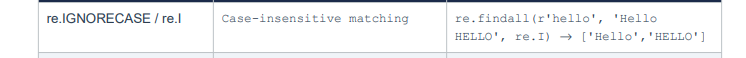

In [66]:
# ❓ Task: Detect Brand Mentions (Case-Insensitive) in Customer Feedback

## 🔹 Scenario (Real DS Use Case)

'''You are analyzing customer feedback data.  
Customers mention the brand **"Nike"**, but in different formats:

- nike  
- NIKE  
- Nike  
- nIkE  

👉 You need to detect all mentions regardless of case.

---

## 🔹 Data

```python'''

import pandas as pd

df = pd.DataFrame({
    'review': [
        'I love Nike shoes',
        'nike quality is great',
        'NIKE is too expensive',
        'Adidas is better',
        'nIkE has good designs'
    ]
})

extract = lambda df, col: df[col].map(lambda x: re.findall(r'\bnike\b', x, re.IGNORECASE))
extract(df, 'review')

0    [Nike]
1    [nike]
2    [NIKE]
3        []
4    [nIkE]
Name: review, dtype: object

In [67]:
# easy way for the above task
result = df[df['review'].str.contains(r'\bnike\b', regex=True, case=False)]
result

,review
0,I love Nike shoes
1,nike quality is great
2,NIKE is too expensive
4,nIkE has good designs


# re.VERBOSE / re.X
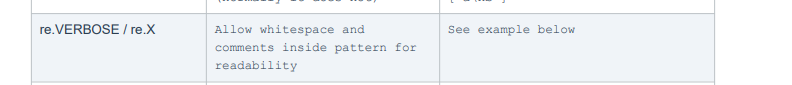

In [68]:
'''❓ Task: Extract Emails from Messy Text using re.VERBOSE

## 🔹 Scenario (Real DS Use Case)

You are working with customer support logs.  
Each message may contain **emails in messy formats**.

👉 Your job is to extract **valid email addresses** using a **readable regex (re.VERBOSE)**'''


import re
import pandas as pd

df = pd.DataFrame({
    'text': [
        'Contact us at support@example.com for help',
        'Send mail to SALES@company.co.in now',
        'Invalid email: user@@domain.com',
        'Another one: test.user+123@gmail.com',
        'No email here',
        'Reach me at admin@site.org or hr@site.org'
    ]
})

pattern = re.compile(r'''
(?<=\b)                    # word boundary before username
[a-zA-Z0-9._%+-]+         # username
(?=@)                     # must be followed by @   ← LOOKAHEAD

@                         # actual @

(?<=@)                    # must be after @         ← LOOKBEHIND
[a-zA-Z0-9.-]+            # domain
\.
[a-zA-Z]{2,}              # TLD
''', re.VERBOSE | re.IGNORECASE)

extract = lambda x: pattern.findall(x)
result = df['text'].map(extract)
result

0            [support@example.com]
1            [SALES@company.co.in]
2                               []
3        [test.user+123@gmail.com]
4                               []
5    [admin@site.org, hr@site.org]
Name: text, dtype: object

# Real DS / DA tasks

In [69]:
# Match Indian mobile numbers: start with 6 or 9 or 8, followed by 9 more digits
text = 'Call 9876543210 or 1234567890 or 8777575516'

re.findall(r'[689]\d{9}', text) # [] - means any char inside the brackets

['9876543210', '8777575516']

# Pandas + Regex Integration ← Daily DA/DS Work


# str.extract() — Extract into DataFrame Columns ← Most Used

In [70]:
# ❓ Task:
# You are given a log column containing:
# - Date
# - Log level (ERROR / INFO)
# - user_id
#
# 👉 Extract the following into separate columns:
# 1. date
# 2. level
# 3. user_id (with label like user_id=101)

import pandas as pd

# Sample Data
df = pd.DataFrame({
    'log': [
        '2024-03-15 ERROR user_id=101 failed',
        '2024-03-16 INFO user_id=202 success'
    ]
})

# 🧠 Regex Explanation:
# (\d{4}-\d{2}-\d{2}) → Capture date (YYYY-MM-DD)
# \s+                → One or more spaces
# (\w+)              → Capture log level (ERROR / INFO)
# \s+                → One or more spaces
# (user_id=\d+)      → Capture full user_id (like user_id=101)

df[['date', 'level', 'errors']] = df['log'].str.extract( r'(\d{4}-\d{2}-\d{2})\s+(\w+)\s+(user_id=\d+)')

df

,log,date,level,errors
0,2024-03-15 ERROR user_id=101 failed,2024-03-15,ERROR,user_id=101
1,2024-03-16 INFO user_id=202 success,2024-03-16,INFO,user_id=202


# str.contains() — Filter Rows with Regex

In [71]:
# ❓ Task:
# You are given a DataFrame with:
# - email column (some valid, some invalid)
# - description column
#
# 👉 Filter ONLY rows where email is VALID
#
# Valid email rules:
# ✔ contains '@'
# ✔ has domain like .com, .in, .org
# ✔ proper structure (text@text.domain)

import pandas as pd

# Sample Data
df = pd.DataFrame({
    'email': [
        'john@gmail.com',
        'invalid_email',
        'mary@yahoo.in',
        'test@company',
        'alex123@domain.org'
    ],
    'description': [
        'Order 123 placed',
        'No numbers here',
        'Invoice 456 generated',
        'Pending approval',
        'ID 789 confirmed'
    ]
})

# 🧠 Regex Explanation:
# [\w.+-]+   → username (letters, digits, ., +, -)
# @          → must contain @
# \w+        → domain name
# \.         → dot before extension
# \w{2,}     → extension (at least 2 characters like com, in, org)

filtered = df[df['email'].str.contains(r'[\w.+-]+@\w+\.\w{2,}',regex=True, na=False)]

filtered

,email,description
0,john@gmail.com,Order 123 placed
2,mary@yahoo.in,Invoice 456 generated
4,alex123@domain.org,ID 789 confirmed


# str.replace() — Clean and Transform Text ← Use regex=True


In [72]:
# ❓ Task:
# You are given a DataFrame with:
# - name (contains special characters)
# - text (extra spaces)
# - raw_html (HTML tags)
#
# 👉 Clean ALL columns by:
# 1. Removing HTML tags like <p>, <div>, etc.
# 2. Removing special characters (!, @, #, %, etc.)
# 3. Keeping only letters, numbers, and spaces

import re
import pandas as pd

# Sample Data
df = pd.DataFrame({
    'name': ['John@123', 'An!ta#45', 'Rohit$%', 'Priya_99'],
    'text': ['Hello   world', 'Data    science   is   fun', '  Machine   learning ', 'AI    is   powerful   '],
    'raw_html': ['<p>Great product</p>', '<div>Bad service</div>', '<p>Fast delivery</p><p>Nice packaging</p>', '<span>Okay</span>']
})

# 🧠 Regex Explanation:
# <[^>]+>        → remove HTML tags
# |              → OR
# [^A-Za-z0-9 ]  → remove special characters (keep letters, digits, spaces)

clean_all = lambda x: re.sub(r'<[^>]+>|[^A-Za-z0-9 ]', ' ', x)

# Columns to clean
cols = ['name', 'text', 'raw_html']

# Apply cleaning:
# apply() → column-wise iteration
# map()   → value-wise cleaning inside each column
df[cols] = df[cols].apply(lambda col: col.map(clean_all))

df

,name,text,raw_html
0,John 123,Hello world,Great product
1,An ta 45,Data science is fun,Bad service
2,Rohit,Machine learning,Fast delivery Nice packaging
3,Priya 99,AI is powerful,Okay


# Above task explanation

# Apply cleaning:
# apply() → column-wise iteration
# map()   → value-wise cleaning inside each column

# 💡 Important:
# re.sub() works on a SINGLE STRING (element level), not on a pandas Series

# 👉 Here:
# 'col' is a FULL COLUMN (Series) like:
# df['name'], df['text'], df['raw_html']

# 👉 So apply() does:
# first → col = df['name']
# second → col = df['text']
# third → col = df['raw_html']

# 👉 Then map() does:
# takes each value inside that column and applies clean_all()

# 🔄 Flow:
# col = df['name'] → ['John@123', 'An!ta#45', ...]
# map(clean_all) →
#    clean_all('John@123')
#    clean_all('An!ta#45')
#    clean_all('Rohit$%')
#    ...

df[cols] = df[cols].apply(lambda col: col.map(clean_all))

In [73]:
# Sample Data
df = pd.DataFrame({
    'name': ['John@123', 'An!ta#45', 'Rohit$%', 'Priya_99'],
    'text': ['Hello   world', 'Data    science   is   fun', '  Machine   learning ', 'AI    is   powerful   '],
    'raw_html': ['<p>Great product</p>', '<div>Bad service</div>', '<p>Fast delivery</p><p>Nice packaging</p>', '<span>Okay</span>']
})

def clean(df, *cols):
    df[list(cols)] = df[list(cols)].apply(lambda x: x.str.replace(r'<[^>]+>|[^A-Za-z0-9 ]', '', regex=True).str.replace(r'\s+', ' ', regex=True).str.strip())
    return df

clean(df, 'name', 'text', 'raw_html')

,name,text,raw_html
0,John123,Hello world,Great product
1,Anta45,Data science is fun,Bad service
2,Rohit,Machine learning,Fast deliveryNice packaging
3,Priya99,AI is powerful,Okay


In [74]:
# now using str.replace
# ❓ Task:
# You are given a DataFrame with:
# - name (contains special characters)
# - text (extra spaces)
# - raw_html (HTML tags)
#
# 👉 Clean ALL columns by:
# 1. Removing HTML tags like <p>, <div>, etc.
# 2. Removing special characters (!, @, #, %, etc.)
# 3. Keeping only letters, numbers, and spaces
# 4. Removing extra spaces (multiple → single space)

import pandas as pd

df = pd.DataFrame({
    'name': [
        'John@123',
        'An!ta#45',
        'Rohit$%',
        'Priya_99'
    ],
    'text': [
        'Hello   world',
        'Data    science   is   fun',
        '  Machine   learning ',
        'AI    is   powerful   '
    ],
    'raw_html': [
        '<p>Great product</p>',
        '<div>Bad service</div>',
        '<p>Fast delivery</p><p>Nice packaging</p>',
        '<span>Okay</span>'
    ]
})

cols = ['name', 'text', 'raw_html']

# 🧠 Regex Explanation:
# <[^>]+>        → remove HTML tags
# |              → OR
# [^A-Za-z0-9 ]  → remove special characters (keep letters, digits, spaces)

# \s+ → matches multiple spaces → replaced with single space

# 💡 Important:
# .str.replace() works on the FULL COLUMN (Series) — vectorized (no Python loop)
# So unlike re.sub(), it can handle Series directly

# 👉 apply():
# loops column-wise → name → text → raw_html

# 👉 Inside:
# col.str.replace(...) applies regex on entire column at once (fast)

df[cols] = df[cols].apply(
    lambda col: col
        .str.replace(r'<[^>]+>|[^A-Za-z0-9 ]', ' ', regex=True)  # remove tags + special chars
        .str.replace(r'\s+', ' ', regex=True)                   # fix multiple spaces
        .str.strip()                                            # remove leading/trailing spaces
)

df


,name,text,raw_html
0,John 123,Hello world,Great product
1,An ta 45,Data science is fun,Bad service
2,Rohit,Machine learning,Fast delivery Nice packaging
3,Priya 99,AI is powerful,Okay


#  str.findall() — Get All Matches as a List Per Row

In [75]:
import pandas as pd

df = pd.DataFrame({
    'text': [
        'Order 100 units at 50 each',
        'Invoice total 2500 with discount 200',
        'No numbers here',
        'Paid 300 and 400 in two parts'
    ]
})

extract = lambda df, col: df[col].str.findall(r'\d+') # same .str.findall() works on the FULL COLUMN (Series) — vectorized (no Python loop)
df['numbers'] = extract(df, 'text')
df

,text,numbers
0,Order 100 units at 50 each,"[100, 50]"
1,Invoice total 2500 with discount 200,"[2500, 200]"
2,No numbers here,[]
3,Paid 300 and 400 in two parts,"[300, 400]"


In [76]:
#⚡ Alternative (best practice)
df = pd.DataFrame({
    'text': [
        'Order 100 units at 50 each',
        'Invoice total 2500 with discount 200',
        'No numbers here',
        'Paid 300 and 400 in two parts'
    ]
})

df['numbers'] = df['text'].str.findall(r'\d+')
df

,text,numbers
0,Order 100 units at 50 each,"[100, 50]"
1,Invoice total 2500 with discount 200,"[2500, 200]"
2,No numbers here,[]
3,Paid 300 and 400 in two parts,"[300, 400]"


In [77]:
import re

# ❓ Question:
# You are given a list of messy product names.
# Clean them by:
# 1. Replacing all special characters with '_'
# 2. Converting multiple '_' into a single '_'
# 3. Removing leading/trailing '_'
# 4. Keeping only letters and numbers (with '_')

products = [
    "  @iPhone-14 Pro!!  ",
    "Samsung___Galaxy S23****",
    "!!OnePlus--11__",
    "   Pixel#7@@@Pro   "
]

# pattern1 → matches unwanted characters (NOT A-Z, a-z, 0-9)
pattern1 = re.compile(r'[^A-Za-z0-9]+')

# pattern2 → matches multiple underscores
pattern2 = re.compile(r'_+')

# 🔍 Syntax:
# pattern.sub(REPLACEMENT, TEXT)
# 👉 replaces what pattern matches with REPLACEMENT

clean = list(map(lambda x: pattern2.sub('_', pattern1.sub('_', x)).strip('_'),products))

print(clean)

['iPhone_14_Pro', 'Samsung_Galaxy_S23', 'OnePlus_11', 'Pixel_7_Pro']


In [129]:
import pandas as pd
import re

logs = pd.DataFrame({'raw': [
    '2024-03-15 10:30:45 ERROR 192.168.1.1 user=raj msg=login_failed',
    '2024-03-15 10:31:02 INFO 10.0.0.5 user=admin msg=success',
    '2024-03-15 10:31:45 WARN 192.168.1.2 user=guest msg=timeout',
]})

def clean(txt):
    pattern = re.compile(
        r'(\d{4}-\d{2}-\d{2})\s+'      # date
        r'(\d{2}:\d{2}:\d{2})\s+'      # time
        r'(\w+)\s+'                    # level
        r'([\d.]+)\s+'                 # ip
        r'user=(\w+)\s+'               # user
        r'msg=(\w+)'                   # msg
    )
    
    return pattern.findall(txt)

# apply on each row
logs['extracted'] = logs['raw'].apply(clean)

# convert list of tuples → columns
cols = ['date', 'time', 'level', 'ip', 'user', 'msg']
logs[cols] = pd.DataFrame(logs['extracted'].str[0].to_list(), index=logs.index)

logs

,raw,extracted,date,time,level,ip,user,msg
0,2024-03-15 10:30:45 ERROR 192.168.1.1 user=raj...,"[(2024-03-15, 10:30:45, ERROR, 192.168.1.1, ra...",2024-03-15,10:30:45,ERROR,192.168.1.1,raj,login_failed
1,2024-03-15 10:31:02 INFO 10.0.0.5 user=admin m...,"[(2024-03-15, 10:31:02, INFO, 10.0.0.5, admin,...",2024-03-15,10:31:02,INFO,10.0.0.5,admin,success
2,2024-03-15 10:31:45 WARN 192.168.1.2 user=gues...,"[(2024-03-15, 10:31:45, WARN, 192.168.1.2, gue...",2024-03-15,10:31:45,WARN,192.168.1.2,guest,timeout


# . Real-World Enterprise Patterns


In [79]:
import re

# ❓ Question:
# Validate whether a given string is a valid email address.
# Rules:
# 1. Username can contain letters, numbers, ., _, %, +, -
# 2. Must contain exactly one @
# 3. Domain must contain letters, numbers, . and -
# 4. Must end with a valid domain like .com, .org, .in (at least 2 letters)

emails = [
    "user@gmail.com",
    "john.doe_123@yahoo.in",
    "bad@.com",
    "noatsymbol.com",
    "user@domain",
    "user@domain.c",
    "valid_email-123@company.org"
]

match = lambda x: list(filter(lambda z: re.fullmatch(r'[\w.+-]+@\w+\.\w{2,}', z), x))
match(emails)

['user@gmail.com', 'john.doe_123@yahoo.in', 'valid_email-123@company.org']

# Where DA/DS Teams Actually Use Regex — Daily Tasks


In [80]:
import pandas as pd
import re

# ❓ Question:
# You are given a dataset with messy data.
# Clean the data by:
# 1. Standardizing phone numbers (remove non-digits, replace leading 0 with 91)
# 2. Cleaning amount column (remove Rs, commas, $ and convert to float)
# 3. Standardizing date format from DD/MM/YYYY → YYYY-MM-DD

# Sample dataset
df = pd.DataFrame({
    'phone': ['0987654321', '+91-98765-43210', '98765 43210'],
    'amount': ['Rs.1,200', '$2,500', '3,000'],
    'date': ['12/03/2024', '05/11/2023', '25/01/2025']
})

# Step 1: Clean phone numbers
# remove everything except digits
df['phone'] = df['phone'].str.replace(r'[^\d]', '', regex=True)

# replace starting 0 with 91
df['phone'] = df['phone'].str.replace(r'^0', '91', regex=True)



# Step 2: Clean amount column
# remove Rs, $, commas
df['amount'] = df['amount'].str.replace(r'[Rs.,$]', '', regex=True)

# convert to float
df['amount'] = df['amount'].astype(float)


# Step 3: Standardize date format
# convert DD/MM/YYYY → YYYY-MM-DD using regex groups

df['date'] = df['date'].str.replace(r'(?P<d>\d{2})/(?P<m>\d{2})/(?P<y>\d{4})',r'\g<y>-\g<m>-\g<d>',regex=True)



print(df)


          phone  amount        date
0   91987654321  1200.0  2024-03-12
1  919876543210  2500.0  2023-11-05
2    9876543210  3000.0  2025-01-25


In [81]:
# HTML cleaning
import re

# ❓ Question:
# You are given messy HTML text.
# Clean it by:
# 1. Removing all HTML tags (<h1>, <p>, <b> etc.)
# 2. Removing HTML entities like &amp;, &lt;, &gt;
# 3. Removing extra spaces (convert multiple spaces → single space)
# 4. Return clean readable text

# Sample input
texts = [
    "<h1>Hello</h1><p><b>World &amp; Python</b></p>",
    "<div>Data&nbsp;Science &lt;AI&gt;</div>",
    "<p>   Machine     Learning   </p>"
]

# 🔹 Function to clean HTML text
def clean_html(text):

    # remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)

    # remove HTML entities (&amp;, &lt;, etc.)
    text = re.sub(r'&[a-z]+;', ' ', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# apply cleaning
cleaned = list(map(clean_html, texts))

print(cleaned)


['Hello World Python', 'Data Science AI', 'Machine Learning']


In [82]:
# NLP

import re

# ❓ Question:
# You are given messy text / tweets.
# Clean and preprocess the text by:
# 1. Converting to lowercase
# 2. Removing URLs
# 3. Removing @mentions and #hashtags
# 4. Removing standalone numbers (keep words like mp3, but remove 123)
# 5. Tokenizing into words (only alphabets, no punctuation)

# Sample data
tweets = [
    "Check this out https://example.com #AI @user123",
    "Learning Python3 is fun!!! #coding",
    "Download mp3 file now 12345",
    "Follow @openai for updates #ML #AI"
]

# 🔹 Function to preprocess text
def preprocess(text):

    # convert to lowercase
    text = text.lower()

    # remove URLs
    text = re.sub(r'https?://\S+', '', text)

    # remove @mentions and #hashtags
    text = re.sub(r'[@#]\w+', '', text)

    # remove standalone numbers
    text = re.sub(r'\b\d+\b', '', text)

    # tokenize words (only alphabets)
    tokens = re.findall(r'\b[a-zA-Z]+\b', text)

    return tokens


# apply preprocessing
processed = list(map(preprocess, tweets))

print(processed)

[['check', 'this', 'out'], ['learning', 'is', 'fun'], ['download', 'file', 'now'], ['follow', 'for', 'updates']]


In [25]:
# logs extraction
# Open text file
with open(r'C:\Users\LENOVO\OneDrive\Desktop\Python\data_extraction_project\script_folder/app.log', 'r') as f:
    readlines = f.readlines()

# Create function
import re
import pandas as pd
def clean(text):
    pattern = re.compile(
        r'(\d{4}-\d{2}-\d{2})\s+'      # date
        r'(\d{2}:\d{2}:\d{2}),\d+\s+'  # time (ignore milliseconds)
        r'(\w+)\s+'                    # level
        r'(\w+)\s+'                    # type (User)
        r'(\d+)\s+'                    # id
        r'(\w+)'                       # status
    )

    result = pattern.search(text)
    if result:
        return result.groups()

parsed = list(map(lambda x: clean(x) if x is not None else None, readlines))
df = pd.DataFrame(parsed, columns=['date', 'time', 'level', 'type', 'id', 'status'])
df

,date,time,level,type,id,status
0,2026-04-21,10:20:32,INFO,User,101,fetched
1,2026-04-21,10:20:39,INFO,User,102,fetched
2,2026-04-21,10:20:44,INFO,User,103,fetched
3,2026-04-21,10:21:01,INFO,User,103,fetched
4,2026-04-21,10:21:02,INFO,User,103,fetched
5,2026-04-21,10:21:02,INFO,User,103,fetched
6,2026-04-21,10:21:03,INFO,User,103,fetched
7,2026-04-21,10:21:04,INFO,User,103,fetched


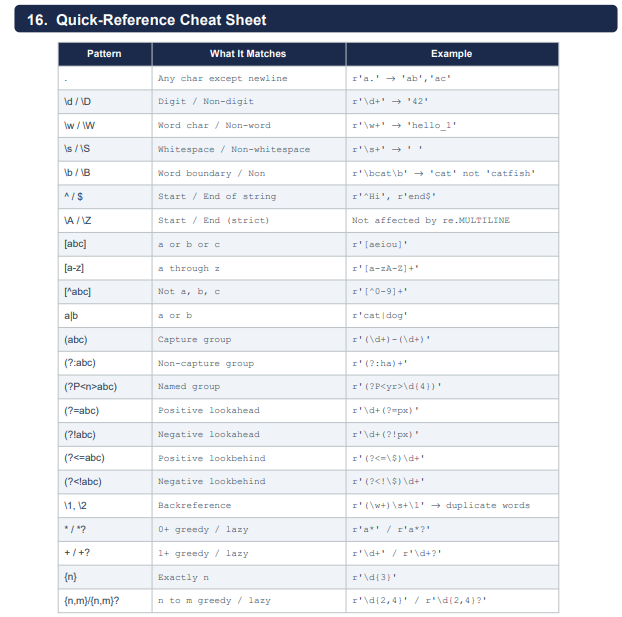

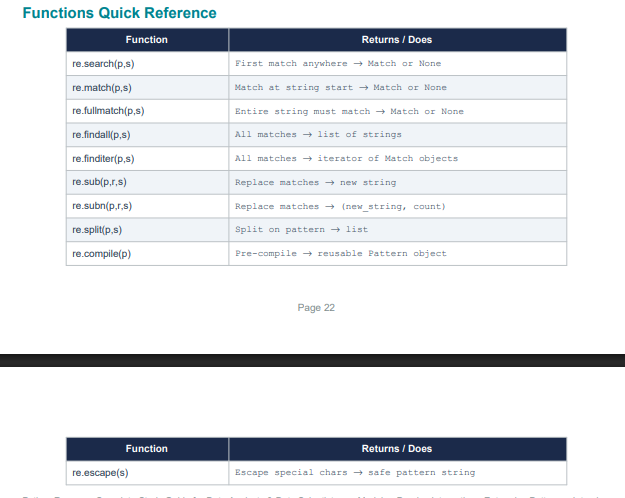

In [83]:
import os
os.getcwd()
os.chdir(r'C:\Users\LENOVO\OneDrive\Desktop\Python\Python_TextFunction')

In [84]:
print(os.getcwd())

C:\Users\LENOVO\OneDrive\Desktop\Python\Python_TextFunction
